In [1]:
import os
# On your second reading, load the compiled rendering backend to save time!
# os.environ["MADRONA_MWGPU_KERNEL_CACHE"] = "<YOUR_PATH>/madrona_mjx/build/cache"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # Ensure that Madrona gets the chance to pre-allocate memory before Jax
os.environ["JAX_DEFAULT_MATMUL_PRECISION"] = "highest" # need this to improve reproducability
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
os.environ["MADRONA_MWGPU_KERNEL_CACHE"] = "/home/chemist/Desktop/ICRA2026/madrona_mjx/build/kernel_cache"
os.environ["MADRONA_BVH_KERNEL_CACHE"] = "/home/chemist/Desktop/ICRA2026/madrona_mjx/build/bvh_cache"

In [3]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools

from brax.training.agents.ppo import networks_vision as ppo_networks_vision
from brax.training.agents.ppo import train as ppo
from flax import linen
from IPython.display import clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
import numpy as np

from mujoco_playground import manipulation
from mujoco_playground import wrapper
from mujoco_playground._src.manipulation.franka_emika_panda import randomize_vision_push as randomize
from mujoco_playground.config import manipulation_params

import pickle # pickle works better
from flax import serialization
import msgpack  # or use `flax.serialization.to_bytes`
np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [4]:
jax.devices()

[CudaDevice(id=0)]

In [5]:
env_name = "PandaPushCube"
env_cfg = manipulation.get_default_config(env_name)

num_envs = 1024
episode_length = int(4 / env_cfg.ctrl_dt)

# Rasterizer is less feature-complete than ray-tracing backend but stable
config_overrides = {
    "episode_length": episode_length,
    "vision": True,
    "proprioception": True,
    "obs_noise.brightness": [0.75, 2.0],
    "vision_config.use_rasterizer": False,
    "vision_config.render_batch_size": num_envs,
    "vision_config.render_width": 64,
    "vision_config.render_height": 64,
    "box_init_range": 0.1, # +- 10 cm
    "action_history_length": 5,
    "success_threshold": 0.03,
    "action_scale": 0.02, # 5 cm,
    "actuator": "position",
    "action": "cartesian_increment",
}

In [6]:


env = manipulation.load(env_name, config=env_cfg,
                        config_overrides=config_overrides
)
randomization_fn = functools.partial(randomize.domain_randomize,
                                        num_worlds=num_envs
)
env = wrapper.wrap_for_brax_training(
    env,
    vision=True,
    num_vision_envs=num_envs,
    episode_length=episode_length,
    action_repeat=1,
    randomization_fn=randomization_fn
)

env.action_size 

self._init_q: [-0.     0.478 -0.001 -1.813 -0.002  2.346  0.785  0.     0.     0.7    0.     0.03   1.     0.
  0.     0.   ]
Using raytracer
loading BVH kernels from cache
Initialization finished
self._init_q: [-0.     0.478 -0.001 -1.813 -0.002  2.346  0.785  0.     0.     0.7    0.     0.03   1.     0.
  0.     0.   ]


3

In [7]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

def tile(img, d):
    assert img.shape[0] == d*d

    img = img.reshape((d,d)+img.shape[1:])
    return np.concat(np.concat(img, axis=1), axis=1)

def unvmap(x):
    return jax.tree.map(lambda y: y[0], x)

somehow the domain randomization is overriding the floor texture

/home/chemist/anaconda3/envs/simtoreal/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:132: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


""

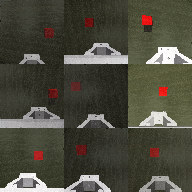

In [8]:
state = jit_reset(jax.random.split(jax.random.PRNGKey(0), num_envs))
# print(state)
# print(state.obs['pixels/view_0'].shape)
media.show_image(tile(state.obs['pixels/view_0'][:9], 3), width=512)

In [9]:
state = jit_reset(jax.random.split(jax.random.PRNGKey(0), num_envs))
rollout = [unvmap(state)]

f = 0.2
for i in range(env_cfg.episode_length):
  action = []
  for j in range(env.action_size):
    action.append(
        jp.sin(
            unvmap(state.data.time) * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
        )
    )
  action = jp.tile(jp.array(action), (num_envs, 1))
  state = jit_step(state, action)
  # print(unvmap(state))
  rollout.append(unvmap(state))
  # media.show_image(
  #     tile(state.obs['pixels/view_0'][:64], 8), width=512
  # )
frames = env.render(rollout, camera="mounted")
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 81/81 [00:00<00:00, 705.20it/s]


This browser does not support the video tag.


In [8]:
network_factory = functools.partial(
    ppo_networks_vision.make_ppo_networks_vision,
    policy_hidden_layer_sizes=[256, 256],
    value_hidden_layer_sizes=[256, 256],
    # activation=linen.relu, # only works with default activation right now
    normalise_channels=True,
    policy_obs_key="_prop" if env_cfg.proprioception else None, # determine wether to use proprioception
    value_obs_key="_prop" if env_cfg.proprioception else None,
)

ppo_params = manipulation_params.brax_vision_ppo_config(env_name)
ppo_params.num_timesteps = 50_000_000
ppo_params.num_envs = num_envs
ppo_params.num_eval_envs = num_envs
del ppo_params.network_factory
ppo_params.network_factory = network_factory

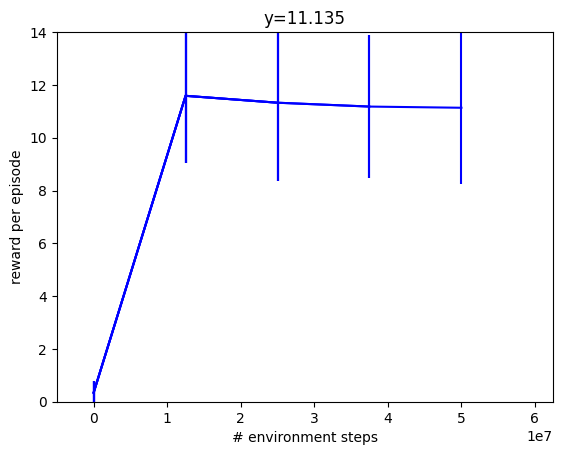

time to jit: 0:01:59.495724
time to train: 1:26:40.895206


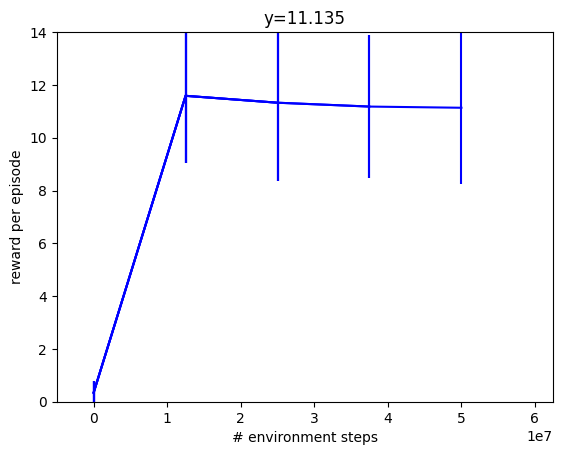

: 

In [ ]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  steps = ppo_params["num_timesteps"]
  plt.xlim([steps * -0.1, steps * 1.25])
  plt.ylim([0, 14])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

train_fn = functools.partial(
    ppo.train,
    augment_pixels=True,
    **dict(ppo_params),
    progress_fn=progress,

)

make_inference_fn, params, metrics = train_fn(environment=env)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(0)
rollout = []
n_episodes = 1
to_keep = 256

def keep_until(state, i):
    return jax.tree.map(lambda x: x[:i], state)

for _ in range(n_episodes):
    key_rng = jax.random.split(rng, num_envs)
    state = jit_reset(key_rng)
    rollout.append(keep_until(state, to_keep))
    for i in range(env_cfg.episode_length):
        act_rng, rng = jax.random.split(rng)
        act_rng = jax.random.split(act_rng, num_envs)
        ctrl, _ = jit_inference_fn(state.obs, act_rng)
        state = jit_step(state, ctrl)
        rollout.append(keep_until(state, to_keep))


In [ ]:
obs = [np.array(s.obs['pixels/view_0']) for s in rollout]
obs = [tile(img, int(np.sqrt(to_keep))) for img in obs]
media.show_video(obs, fps=1.0/env_cfg.ctrl_dt, width=512)

In [ ]:
# Serialize to bytes
param_bytes = serialization.to_bytes(params)

# Save to file
with open("policy_params_general_3d_image_aug_black_white_strip.msgpack", "wb") as f:
    f.write(param_bytes)

In [ ]:
# Load from file
with open("policy_params_general.msgpack", "rb") as f:
    param_bytes = f.read()
    # Deserialize from bytes
    
    loaded_params = serialization.from_bytes(params, param_bytes)
loaded_params


In [ ]:
# Save the params object to a file
with open("policy_params_general_3d_256_image_aug_black_white_strip.pkl", "wb") as f:
    pickle.dump(params, f)

In [ ]:
with open("params_general_3d.pkl", "rb") as f:
    loaded_params = pickle.load(f)
loaded_params

In [ ]:
from flax.traverse_util import flatten_dict

# Flatten the loaded parameters dictionary
flattened_params = flatten_dict(loaded_params[1])  # Assuming the policy params are in the second element of the tuple

# Tabulate the flattened parameters
for key, value in flattened_params.items():
    print(f"{'/'.join(key)}: {value.shape if hasattr(value, 'shape') else value}")

In [ ]:
rng = jax.random.PRNGKey(0)
rollout = []
n_episodes = 1
to_keep = 256

def keep_until(state, i):
    return jax.tree.map(lambda x: x[:i], state)

for _ in range(n_episodes):
    key_rng = jax.random.split(rng, num_envs)
    state = jit_reset(key_rng)
    rollout.append(keep_until(state, to_keep))
    for i in range(env_cfg.episode_length):
        act_rng, rng = jax.random.split(rng)
        act_rng = jax.random.split(act_rng, num_envs)
        ctrl, _ = jit_inference_fn(state.obs, act_rng)
        state = jit_step(state, ctrl)
        rollout.append(keep_until(state, to_keep))

render_every = 1
frames = env.render([unvmap(s) for s in rollout][::render_every], camera="mounted")
rewards = [unvmap(s).reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)
plt.figure(figsize=(3, 2))
plt.plot(rewards)
plt.xlabel("time step")
plt.ylabel("reward")
plt.show()